**Notebook Notes**

v3 of this notebook was revised from v2 to use pipelines for all regressions and calculate r2 as well as RMSE for each model.

Other changes include:
- dropped variables that did not add meaning (seg_missing_bool, denominator of non-physician ratio) and adjusted the standardizze function accordingly 

# 1. Imports

In [688]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import math
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, learning_curve, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn import __version__ as sklearn_version
import statsmodels.api as sm


from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import RidgeCV
from sklearn.base import BaseEstimator, RegressorMixin

from sklearn.svm import LinearSVR # Linear Support Vector Regression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression

In [689]:
from sklearn.dummy import DummyRegressor


In [690]:
!brew reinstall libomp

==> Fetching downloads for: libomp
✔︎ Bottle Manifest libomp (21.1.8)                  [Downloaded   11.9KB/ 11.9KB]✔︎ Bottle Manifest libomp (21.1.8)                  [Downloaded   11.9KB/ 11.9KB]
⠋ Bottle libomp (21.1.8)                           [Downloading 593.7KB/593.7KB]✔︎ Bottle libomp (21.1.8)                           [Downloaded  593.7KB/593.7KB]
==> Reinstalling libomp 
==> Pouring libomp--21.1.8.sonoma.bottle.tar.gz
==> Caveats
libomp is keg-only, which means it was not symlinked into /usr/local,
because it can override GCC headers and result in broken builds.

For compilers to find libomp you may need to set:
  export LDFLAGS="-L/usr/local/opt/libomp/lib"
  export CPPFLAGS="-I/usr/local/opt/libomp/include"
==> Summary
🍺  /usr/local/Cellar/libomp/21.1.8: 9 files, 1.8MB
==> Running `brew cleanup libomp`...
Disable this behaviour by setting `HOMEBREW_NO_INSTALL_CLEANUP=1`.
Hide these hints with `HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).


In [691]:
#!pip uninstall xgboost - ran this in terminal because it requires Y/n prompt
#
!pip uninstall -y xgboost
!pip install xgboost
# Successfully installed xgboost-3.1.2


Found existing installation: xgboost 3.1.2
Uninstalling xgboost-3.1.2:
  Successfully uninstalled xgboost-3.1.2
  Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.2-py3-none-macosx_10_15_x86_64.whl (2.4 MB)


In [692]:
#!pip install xgboost
import xgboost as xgb

Had to do a fair amount of work in Terminal before I could successfully import xgboost. a few notes

Homebrew installed OpenMP here:
- /usr/local/Cellar/libomp/21.1.7/lib/libomp.dylib
- /usr/local/opt/libomp/lib

Created a symlink (shortcut) inside Anaconda pointing to the real file:
ln -s /usr/local/opt/libomp/lib/libomp.dylib /Users/grace/anaconda3/lib/libomp.dylib


# 2. Redefine scaler and imputer functions

## Standardizze fxn

In [693]:

def standardizze (df_train, df_test):
    '''standardize numeric values except 'year'
    df_train - design matrix X_train
    df_test - test design matrix X_test
    returns two data frames: X_train, X_test with standardized data for select columns'''
    # save original shapes
    original_train_shape = df_train.shape
    original_test_shape = df_test.shape

    print(f"***** Dataframe that will not be standardized*****\n")
    dont_std_cols = [col for col in df_train.columns if col.startswith('OH_')] + ['year']+ ['county_name']
    print(f" Columns that wont be standardized: {dont_std_cols}")
    print(f" Is county_name in list that of cols that will not be standardized? {'county_name' in dont_std_cols}\n")
    print(f"\n***** Dataframe to be standardized*****\n")
    # create subset of df with only numeric cols to be standardized
    cols_to_std = df_train.select_dtypes(include = ['int','float']).columns.to_list()
    cols_to_std = [
        col for col in df_train.columns
        if col not in dont_std_cols
        and pd.api.types.is_numeric_dtype(df_train[col])
]

    print("Overlap:", set(cols_to_std) & set(dont_std_cols))
    
    print(f"Dataframe to be standardized - shape: {df_train[cols_to_std].shape}\n")

    # create versions of each df with data that won't be standardized in scaler
    # train & test df's
    train_no_std_df = df_train[dont_std_cols]
    test_no_std_df = df_test[dont_std_cols]
    print(f"df_train of columns that will not be standardized has this shape: {train_no_std_df.shape}")
    print(f"df_test of columns that will not be standardized has this shape: {test_no_std_df.shape}\n")
    # print(f"and these data types are: \n{dont_std_cols_df.dtypes.value_counts()}")

    # scale the columns identified for standardization
    print(f"***** Scaling subsets of the data .... *****\n")
    # train scaler on X_train
    scaler = StandardScaler()
    scaler.fit(df_train[cols_to_std])
    scaled_array = scaler.transform(df_train[cols_to_std])
    df_train_std = pd.DataFrame(scaled_array, columns=cols_to_std, index=df_train.index)
    print(f"Standardized X training df has this shape: {df_train_std.shape}")

    # apply same scaler to X_test
    scaled_array2 = scaler.transform(df_test[cols_to_std])
    df_test_std = pd.DataFrame(scaled_array2, columns=cols_to_std, index=df_test.index)
    print(f"Standardized X test df has this shape: {df_test_std.shape}\n")

    overlap = set(df_train_std.columns) & set(train_no_std_df.columns)
    if overlap:
        raise ValueError(f"Overlapping columns during concat: {overlap}")

    # recombine unstandardized data with standardized data
    # recombine X_train
    X_train_testing = pd.concat([df_train_std, train_no_std_df], axis=1)
    X_test_testing = pd.concat([df_test_std, test_no_std_df], axis=1)

    print(f"***** Assess changes and save with select standardized columns *****\n")
    # assess work and save 


    X_train = X_train_testing  # Default to the processed version
    X_test = X_test_testing
    
    # assess work and save 
    if original_train_shape == X_train_testing.shape:
        print(f"New version of X_train saved over the original version with standardized values") 
    else:
        print(f"Error occured. Shape mismatch for X_train")
        print(f"The shape of X_train_testing is {X_train_testing.shape} but its original shape was {original_train_shape}")
        print(f"Original df_train columns: {df_train.columns}")
        print(f"Modified df_train columns: {X_train_testing.columns}")
        X_train_testing_set = set(X_train_testing.columns.to_list())
        X_train_original_set = set(df_train.columns.to_list())
        difference_train = X_train_testing_set - X_train_original_set
        print(f"The difference between the training data sets is the column(s) : {difference_train}")

    if original_test_shape == X_test_testing.shape:
        print("New version of X_test saved over the original version with standardized values") 
    else:
        print(f"Error occured. Shape mismatch for X_test")
        print(f"The shape of X_test_testing is {X_test_testing.shape} but its original shape was {original_test_shape}") 
    
    print(f"Returning X_train and X_test.")
    print(f"X_train type: {type(X_train)}\nX_test type: {type(X_test)}")
    return X_train, X_test

## Impute_please fxn

In [694]:
def impute_please (X_train, X_test,per_change_thresh):
    '''impute based on existing values for variables where we can assume the county value will not change from year to year
        X_train - design matrix
        X_test - test design matrix
        per_change_thresh - decimal used to define 'little change' over the 4 years
            For example (0.03) would impute county-specific means based on other years of data for any column that changed 
            less than 3% over the four years
        Remember the impute_please function requires 'county_name' as a column since it's imputing based on county membership
        returns X_train, X_test data frames with imputed data and no missing values'''
    # save original shapes
    original_train_shape = X_train.shape
    original_test_shape = X_test.shape
    
    # 1. Simple Imputation
    
    # print variables that are missing at least one value
    X_train_missing_summary_df = pd.DataFrame({'# Missing':X_train.isnull().sum(),'% Missing': round(X_train.isnull().sum()/len(X_train),2)})
    X_train_missing_summary_df =X_train_missing_summary_df[X_train_missing_summary_df['# Missing']>(per_change_thresh*100)].sort_values(by = '% Missing', ascending=False)
    # print(X_train_missing_summary_df)
    cols_missing_data = X_train_missing_summary_df.index.to_list()

    # identify first group of variables for imputation based on the fact that they are fairly constant over the 4 years
    cols_missing_data_plus_year = cols_missing_data +['year']
    print(type(X_train[cols_missing_data_plus_year]))

    # dynamically set the first and last year in data    
    min_year = X_train['year'].min()
    max_year = X_train['year'].max()

    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
    cols_little_changes = [
        col for col in X_train[cols_missing_data_plus_year].columns 
        if col != 'year' and 
        abs((means_by_year.loc[max_year, col] - means_by_year.loc[min_year, col]) / means_by_year.loc[min_year, col]) * 100 < (per_change_thresh*100)
    ]
    print(f"Comparing years {min_year} to {max_year}")
    print(f"Imputing values for columns with <{per_change_thresh*100}% change.....\nThese columns are: {cols_little_changes}")
    
    # replace variables that are fairly constant with their median value across all counties/years
    imputer = SimpleImputer(strategy = 'median', add_indicator = False)

    for col in cols_little_changes:
        # fit on training data
        imputer.fit(X_train[[col]])
        x = imputer.transform(X_train[[col]])
        y = imputer.transform(X_test[[col]])

        # Impute Training & test data
        # convert resulting array to df
        imputed_train_col_df = pd.DataFrame(x, columns = [col], index= X_train.index)
        imputed_test_col_df = pd.DataFrame(y, columns = [col], index= X_test.index)

        print("Check results for training data set:")
        print(f"Original df missing count for this column: {X_train[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_train_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_train[col].shape}")
        print(f"Shape of modified column: {imputed_train_col_df[col].shape}")
        
        X_train_testing = X_train.copy()
        X_train_testing[col] = imputed_train_col_df[col] # save imputed data over original
        
        if X_train_testing.shape == X_train.shape:
            X_train = X_train_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_train_testing over X_train")
            print(f"Original X_train df shape: {X_train.shape}")
            print(f"Modified X_train df shape: {X_train_testing.shape}")  

        print("Check results for testing data set:")
        print(f"Original df missing count for this column: {X_test[col].isna().sum()}")
        print(f"Modified df missing count for this column: {imputed_test_col_df[col].isna().sum()}")

        print(f"Shape of original column: {X_test[col].shape}")
        print(f"Shape of modified column: {imputed_test_col_df[col].shape}")
        
        X_test_testing = X_test.copy()
        X_test_testing[col] = imputed_test_col_df[col] # save imputed data over original
        
        if X_test_testing.shape == X_test.shape:
            X_test = X_test_testing # save newly imputed values for that column
            print(f"Imputed values saved for {col}\n")
        else: 
            print(f"Error occured. Did not save modified df X_test_testing over X_train")
            print(f"Original X_test df shape: {X_test.shape}")
            print(f"Modified X_test df shape: {X_test_testing.shape}")  
            
    print("Final results of simple imputation with median for select features:")
    print("Training df:")
    print(X_train[cols_little_changes].isna().sum().sort_values(ascending = False)) 
    print("\nTesting df:")
    print(X_test[cols_little_changes].isna().sum().sort_values(ascending = False))      

    
    # 2. Interpolate remaining variables


    # identify 2nd group of variables for imputation that vary over the defined threshold
#    means_by_year = X_train[cols_missing_data_plus_year].groupby('year').mean()    
#    cols_larger_changes = [
#        col for col in X_train[cols_missing_data_plus_year].columns 
#        if col != 'year' and 
#        abs((means_by_year.loc[2023, col] - means_by_year.loc[2020, col]) / means_by_year.loc[2020, col]) * 100 >= (per_change_thresh*100)
#    ]
#    print(f"\nImputing values for {len(cols_larger_changes)} columns with =>{per_change_thresh*100}% change.....\nThese columns are: {cols_larger_changes}")


    # identify remaining columns to impute
    difference = set(X_train.columns) - set(cols_little_changes)
    # Always include 'year' (adding to a set is idempotent - no duplicates)
    difference.add('year')
    # Convert to list if needed
    remaining_cols_to_impute = list(difference)
    print(f"\nImputing values for {len(remaining_cols_to_impute)} columns with missing values....\nThese columns are: {remaining_cols_to_impute}")
    
    # Apply linear interpolation
    # Training data
    # sort rows by county and year to interpolate each missing value according to its county
    X_train = X_train.sort_values(by = ['county_name','year'])

    # make sure cols to impute are only numeric, don't include county
    numeric_remaining_cols = (
    X_train[remaining_cols_to_impute]
    .select_dtypes(include="number")
    .columns
    )
    
    # apply interpolate command to one county at a time with year values in different rows
    X_train[numeric_remaining_cols] = (
        X_train.groupby('county_name')[numeric_remaining_cols]
            .transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear').ffill().bfill())
    )
    print("\nFinal results of interpolation on:")
    print("Training df:")
    print(X_train[numeric_remaining_cols].isna().sum())

    # Apply linear interpolation
    # Testing data
    print("Testing df:")
    X_test = X_test.sort_values(by = ['county_name','year'])
    
    # make sure cols to impute are only numeric, don't include county
    numeric_remaining_cols = (
    X_test[remaining_cols_to_impute]
    .select_dtypes(include="number")
    .columns
    )
    
    # apply interpolate command to one county at a time with year values in different rows
    X_test[numeric_remaining_cols] = (
        X_test.groupby('county_name')[numeric_remaining_cols]
            .transform(lambda x: x.infer_objects(copy=False).interpolate(method='linear').ffill().bfill())
    )
    print(X_test[numeric_remaining_cols].isna().sum())

    
    # 3. Impute the remaining missing values globally (regardless of year or county) 
    # global imputation

    for var in numeric_remaining_cols:
        # Calculate median from TRAINING data only
        train_median = X_train[var].median()
        
        # Apply to both train and test
        X_train[var].fillna(train_median, inplace=True)
        X_test[var].fillna(train_median, inplace=True) 

    print("\nFinal results after global imputation:")
    print("Training df:")
    print(X_train[numeric_remaining_cols].isna().sum())
    print("\nTest df:")
    print(X_test[numeric_remaining_cols].isna().sum())


    print(f"***** Check and save with select standardized columns *****\n")
    # assess work and save 
    print(f"X_train is a {type(X_train)}; X_test is a {type(X_test)}")
    print(f"The shape of X_train is {X_train.shape}; its original shape was {original_train_shape}")
    print(f"The shape of X_test is {X_test.shape}; its original shape was {original_test_shape}")
    print(f"The final number of missing values in X_train is {X_train.isna().sum()}")
    print(f"The final number of missing values in X_test is {X_test.isna().sum()}")
    
    return X_train, X_test


# 3. Models on Group Split - Investigate how features do or do not influence MMR coverage

## 3a. Load data


In [695]:
print(os.getcwd())  # get current working directory

/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split


In [696]:
os.chdir('/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/group_split/')

In [697]:
def import_multiple_csv_to_pandas(filename):
    df = pd.read_csv(filename) 
    print(f"\nDataFrame before conversion:")
    #print(f"Dtypes:\n{df.dtypes}\n")
    print(f"NaN count per column:\n{df.isna().sum()}")
    print(f"Total NaN: {df.isna().sum().sum()}")
    return df

In [698]:
file_names = ["X_train.csv", 
              "y_train.csv", 
              "X_test.csv", 
              "y_test.csv"]

In [699]:
# Import data to data frames
X_train_df = import_multiple_csv_to_pandas(file_names[0])
y_train_df = import_multiple_csv_to_pandas(file_names[1])
X_test_df = import_multiple_csv_to_pandas(file_names[2])
y_test_df = import_multiple_csv_to_pandas(file_names[3])


DataFrame before conversion:
NaN count per column:
county_name                                        0
% Low Birthweight                                423
# Primary Care Physicians                         61
Primary Care Physicians Rate                      61
% Vaccinated Flu                                   4
% Children in Poverty                              0
Infant Mortality Rate                            555
# Uninsured Children                               0
% Uninsured Children                               0
# Food Insecure                                    0
% Food Insecure                                    0
Segregation index_b                              254
Other Primary Care Provider Rate                  13
Median Household Income                            0
% Enrolled in Free or Reduced Lunch                0
Population                                         0
% Female                                         198
% Rural                                        

In [700]:
print('seg_missing_bool' in X_train_df.columns)
print('seg_missing_bool' in X_test_df.columns)


True
True


In [701]:
# Drop pesky columns
X_train_df = X_train_df.drop('seg_missing_bool', axis=1)
X_test_df  = X_test_df.drop('seg_missing_bool', axis=1)


In [702]:
print("There are no vars that shouldn't be there:",'seg_missing_bool' in X_train_df.columns)
print("There are no vars that shouldn't be there:",'CVAC level of Concern' in X_train_df.columns)

There are no vars that shouldn't be there: False
There are no vars that shouldn't be there: False


In [703]:
X_train_df.select_dtypes(include = 'object')
X_test_df.select_dtypes(include = 'object')

,county_name
0,Aransas
1,Bailey
2,Bell
3,Bowie
4,Brooks
...,...
194,Upshur
195,Victoria
196,Webb
197,Willacy


In [704]:
# Convert only y_test and y_train to numpy arrays
y_test_array = y_test_df.to_numpy().ravel()
y_train_array = y_train_df.to_numpy().ravel()

print("y_test array:")
print(" Shape:", y_test_array.shape)
print(" Dtype:", y_test_array.dtype)

print("y_train array:")
print(" Shape:", y_train_array.shape)
print(" Dtype:", y_train_array.dtype)

y_test array:
 Shape: (199,)
 Dtype: float64
y_train array:
 Shape: (797,)
 Dtype: float64


In [705]:
# check to see if country_name is in the X_train file, will need this for imputation fxn
X_train_df.index
'county_name' in (X_train_df.columns)

# extract index to X_train
feature_names = X_train_df.columns.to_list()

In [706]:
# apply standardizer fxn to X_train and X_test
X_train_processed, X_test_processed = standardizze(X_train_df, X_test_df)

***** Dataframe that will not be standardized*****

 Columns that wont be standardized: ['year', 'county_name']
 Is county_name in list that of cols that will not be standardized? True


***** Dataframe to be standardized*****

Overlap: set()
Dataframe to be standardized - shape: (797, 31)

df_train of columns that will not be standardized has this shape: (797, 2)
df_test of columns that will not be standardized has this shape: (199, 2)

***** Scaling subsets of the data .... *****

Standardized X training df has this shape: (797, 31)
Standardized X test df has this shape: (199, 31)

***** Assess changes and save with select standardized columns *****

New version of X_train saved over the original version with standardized values
New version of X_test saved over the original version with standardized values
Returning X_train and X_test.
X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>


In [707]:
# Apply the impute_please fxn to X_train and X_test
# remember the impute_please function requires 'county_name' as a column
X_train_processed, X_test_processed = impute_please(X_train_processed, X_test_processed, 0.03)

<class 'pandas.core.frame.DataFrame'>
Comparing years 2020 to 2023
Imputing values for columns with <3.0% change.....
These columns are: []
Final results of simple imputation with median for select features:
Training df:
Series([], dtype: float64)

Testing df:
Series([], dtype: float64)

Imputing values for 33 columns with missing values....
These columns are: ['Other Primary Care Provider Rate', 'kin_DTP_cov', '# Uninsured Children', 'Estimated strongly hesitant', '% Vaccinated Flu', '% Rural', 'Estimated hesitant or unsure', 'Infant Mortality Rate', 'kin_HepA_cov', '% Female', '% Uninsured Children', 'Median Household Income', 'Population', 'CVAC level of concern for vaccination rollout', 'Segregation index_b', 'kin_HepB_cov', 'Primary Care Physicians Rate', '% Food Insecure', 'other_pc_provider_ratio_numerator', 'kin_varic_cov', 'county_name', '% Low Birthweight', 'Social Vulnerability Index (SVI)', '# Food Insecure', '% Less Than 18 Years of Age', 'live_births', 'Estimated hesitant

#### Convert index to numeric and remove county_name before modeling

In [708]:
type(X_train_processed)

pandas.core.frame.DataFrame

In [709]:
# Process X_train and X_test
# Make sure there indices are numeric before modeling, delete 'column', rename and convert to numpy

for df in [X_train_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_train = df.to_numpy()

for df in [X_test_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_test = df.to_numpy()

Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=797, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=199, step=1)
Dataframe has county as a column AFTER modification? False
5


In [710]:
# last data type and shape checks
print(f"X_train type: {type(X_train)}\nX_test type is{type(X_test)}.")
print(f"X_train shape: {X_train.shape}\nX_test type is{X_test.shape}.")

print(f"y_train type: {type(y_train_df)}\ny_test type is{type(y_test_df)}.")
print(f"y_train type: {y_train_df.shape}\ny_test type is{y_test_df.shape}.")

feature_names.remove('county_name')
print(len(feature_names))

X_train type: <class 'numpy.ndarray'>
X_test type is<class 'numpy.ndarray'>.
X_train shape: (797, 32)
X_test type is(199, 32).
y_train type: <class 'pandas.core.frame.DataFrame'>
y_test type is<class 'pandas.core.frame.DataFrame'>.
y_train type: (797, 1)
y_test type is(199, 1).
32


In [711]:
# flatten y arrays
y_test = y_test_array.ravel()
y_train = y_train_array.ravel()

In [712]:
print(y_test.shape, y_train.shape)

(199,) (797,)


## 3b. Models

In [713]:
# specify cross validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=1)
# Define the scoring function for selectKBest
# f_regression (F-value) is a common choice for numerical data and linear relationships
score_func = f_regression 

### Dummy Regressor

In [714]:
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
dummy_score = dummy.score(X_train, y_train)
print(f"Dummy model R²: {dummy_score}")

Dummy model R²: 0.0


### LinearRegression

In [715]:
# create pipeline and fit to data
lr1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 5 features
    ("regressor", LinearRegression())
])


In [716]:
# Evaluate the model
scores = cross_val_score(lr1, X_train, y_train, cv=kf, scoring='neg_mean_squared_error')
print(scores)
rmse_scores = np.sqrt(-scores)
print("RMSE scores for each fold:",rmse_scores)

print("Mean RMSE across all folds:", rmse_scores.mean())
print("Standard deviation of RMSE across all folds:", rmse_scores.std())

[-0.00206081 -0.00113566 -0.0018285  -0.0024803  -0.00200196]
RMSE scores for each fold: [0.0453961  0.0336996  0.04276093 0.04980258 0.04474321]
Mean RMSE across all folds: 0.04328048548688165
Standard deviation of RMSE across all folds: 0.005314440609632437


In [717]:
lr1.fit(X_train, y_train)

Pipeline(steps=[('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x14b4f2660>)),
                ('regressor', LinearRegression())])

In [718]:
# calculate R squared 
lr1.score(X_train, y_train)

0.0328020181323182

In [719]:
# view pipeline's step names
print(lr1.named_steps.keys())

dict_keys(['feature_selection', 'regressor'])


In [720]:
# Get the SelectKBest step from your pipeline
selector = lr1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [721]:
print(len(feature_names))
print(len(selected_features))

32
10


feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: coefficient, dtype: float64


(array([-0.006, -0.004, -0.002,  0.   ,  0.002,  0.004,  0.006,  0.008,
         0.01 ,  0.012,  0.014]),
 [Text(-0.006, 0, '−0.006'),
  Text(-0.004, 0, '−0.004'),
  Text(-0.002, 0, '−0.002'),
  Text(0.0, 0, '0.000'),
  Text(0.002, 0, '0.002'),
  Text(0.004, 0, '0.004'),
  Text(0.006, 0, '0.006'),
  Text(0.008, 0, '0.008'),
  Text(0.01, 0, '0.010'),
  Text(0.012000000000000002, 0, '0.012'),
  Text(0.014, 0, '0.014')])

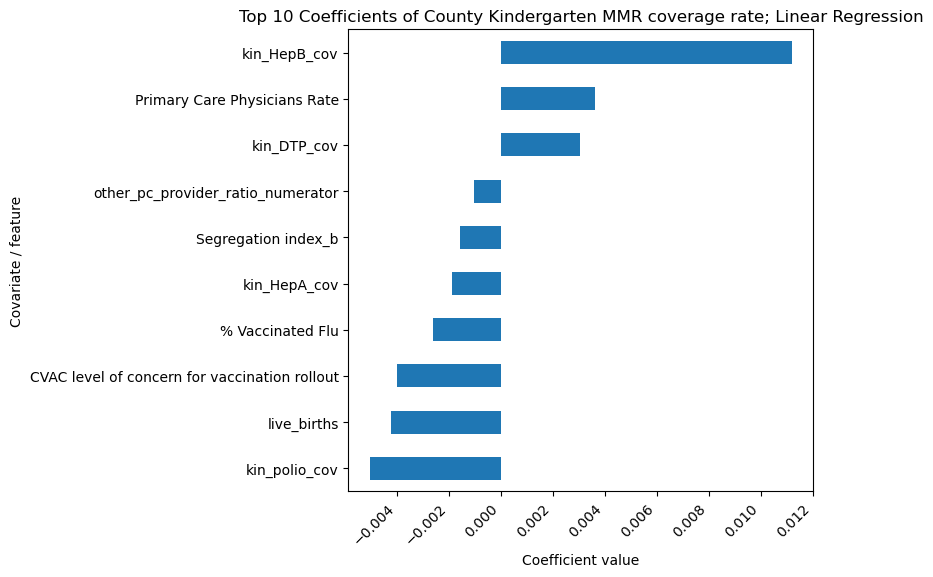

In [723]:
# Extract feature importance (coefficients from pipeline)
coefs = lr1.named_steps["regressor"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series = coef_df.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_sorted = coef_series.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs = coef_series_sorted.head(10)
print(top10_coefs)
# Plot horizontally
_ = top10_coefs.sort_values().plot.barh(figsize=(6,6))
plt.title("Top 10 Coefficients of County Kindergarten MMR coverage rate; Linear Regression")
plt.ylabel("Covariate / feature")
plt.xlabel("Coefficient value")
# rotate x-axis tick labels
plt.xticks(rotation=45, ha='right')

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
Name: coefficient, dtype: float64


(array([-0.006, -0.004, -0.002,  0.   ,  0.002,  0.004,  0.006,  0.008,
         0.01 ,  0.012,  0.014]),
 [Text(-0.006, 0, '−0.006'),
  Text(-0.004, 0, '−0.004'),
  Text(-0.002, 0, '−0.002'),
  Text(0.0, 0, '0.000'),
  Text(0.002, 0, '0.002'),
  Text(0.004, 0, '0.004'),
  Text(0.006, 0, '0.006'),
  Text(0.008, 0, '0.008'),
  Text(0.01, 0, '0.010'),
  Text(0.012000000000000002, 0, '0.012'),
  Text(0.014, 0, '0.014')])

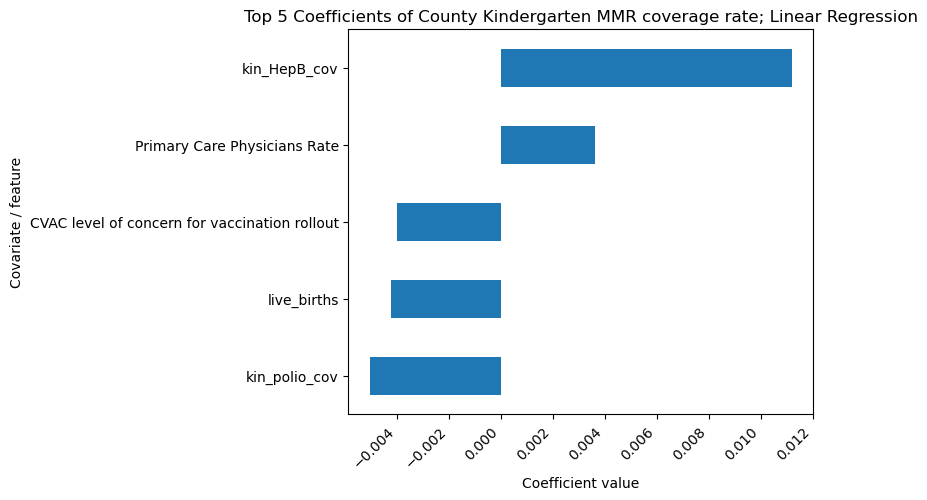

In [736]:
top5_coefs = coef_series_sorted.head(5)
print(top5_coefs)
# Plot horizontally
_ = top5_coefs.sort_values().plot.barh(figsize=(6,5))
plt.title("Top 5 Coefficients of County Kindergarten MMR coverage rate; Linear Regression")
plt.ylabel("Covariate / feature")
plt.xlabel("Coefficient value")
# rotate x-axis tick labels
plt.xticks(rotation=45, ha='right')

Use trained model to predict coverage for new county-years

In [544]:
# try using model to predict coverage for new counties
y_pred = lr1.predict(X_test)

In [545]:
# instantiate a negative MSE scorer
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)
neg_mse = neg_mse_scorer(lr1, X_test, y_test)
print(f"Negative MSE: {neg_mse}")
print(f"RMSE: {np.sqrt(-neg_mse)}")

Negative MSE: -0.0010817292014680677
RMSE: 0.0328896518903449


In [546]:
# calculate R squared 
lr1.score(X_test, y_test)


-0.09056520298922388

Dismal score on the training and test data sets.

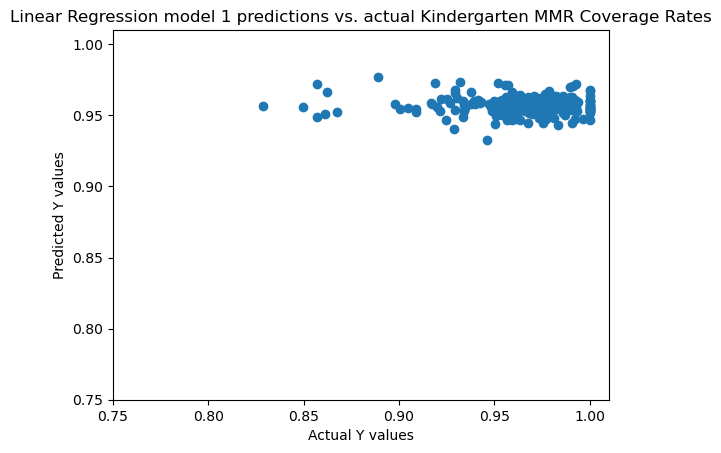

In [547]:
plt.scatter(y_test,y_pred)
# Set axis limits starting at 0.75
plt.xlim(0.75, 1.01)  # Add 5% padding
plt.ylim(0.75, 1.01)
plt.xlabel("Actual Y values")
plt.ylabel("Predicted Y values")
plt.title("Linear Regression model 1 predictions vs. actual Kindergarten MMR Coverage Rates")
plt.show()

THis looks like a pretty poor model, doesn't seem to be much relationship at all between the actual values and predicted values, which makes sense given the R squared value was only about 5%

### OLS

OLS cannot be directly inserted into a pipeline, create a wrapper for this

In [548]:
class SMWrapper(BaseEstimator, RegressorMixin):
    """Wrapper for statsmodels OLS to work with sklearn pipelines"""
    def __init__(self, add_constant=True):
        self.add_constant = add_constant
    
    def fit(self, X, y):
        if self.add_constant:
            X = sm.add_constant(X)
        self.model_ = sm.OLS(y, X).fit()
        return self
    
    def predict(self, X):
        if self.add_constant:
            X = sm.add_constant(X)
        return self.model_.predict(X)


In [549]:
# Create pipeline with the wrapper
ols1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top features
    ("regressor", SMWrapper(add_constant=True))
])

In [550]:
ols1.fit(X_train, y_train)
ols1_results = ols1.named_steps['regressor'].model_
print(ols1_results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     2.666
Date:                Sun, 28 Dec 2025   Prob (F-statistic):            0.00330
Time:                        02:14:27   Log-Likelihood:                 1390.6
No. Observations:                 797   AIC:                            -2759.
Df Residuals:                     786   BIC:                            -2708.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0131      2.825      1.067      0.2

Result summary showed small R squared of < 0.5

In [551]:
print(f"R-squared: {ols1_results.rsquared:.4f}")
print(f"Adjusted R-squared: {ols1_results.rsquared_adj:.4f}")
print(f"MSE: {ols1_results.mse_resid:.4f}")
print(f"RMSE: {np.sqrt(ols1_results.mse_resid):.4f}")

R-squared: 0.0328
Adjusted R-squared: 0.0205
MSE: 0.0018
RMSE: 0.0426


Performed much better on test data. Regularization is probably helping prevent overfitting.

**Question**: If my primary research question is interested in predictors, would i look at the coefficients from the model estimates on training data or on test data?

Take them from training set fitting, more data. But still report how well model generalizes

In [552]:
# Extract coefficients
coefs = ols1_results.params  # pandas Series with index = feature names
coefs = coefs[1:] # slice off first column of array which is the constant we added
coefs.shape 

(10,)

In [553]:
# Get the SelectKBest step from your pipeline
selector = ols1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [554]:
selector

SelectKBest(score_func=<function f_regression at 0x14b4f2660>)

In [555]:
selected_features

['Primary Care Physicians Rate',
 '% Vaccinated Flu',
 'Segregation index_b',
 'live_births',
 'kin_DTP_cov',
 'kin_HepA_cov',
 'kin_HepB_cov',
 'kin_polio_cov',
 'CVAC level of concern for vaccination rollout',
 'other_pc_provider_ratio_numerator']

In [556]:
len(selected_features)

10

In [557]:
# Set index to feature name, extract coefficient series
coef_df = pd.DataFrame({'coefficients': coefs}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)

,coefficients,coef_magnitude
kin_HepB_cov,0.011213,0.011213
kin_polio_cov,-0.005043,0.005043
live_births,-0.004206,0.004206
CVAC level of concern for vaccination rollout,-0.003993,0.003993
Primary Care Physicians Rate,0.003629,0.003629
kin_DTP_cov,0.003063,0.003063
% Vaccinated Flu,-0.002611,0.002611
kin_HepA_cov,-0.001878,0.001878
Segregation index_b,-0.001568,0.001568
other_pc_provider_ratio_numerator,-0.001017,0.001017


<Axes: >

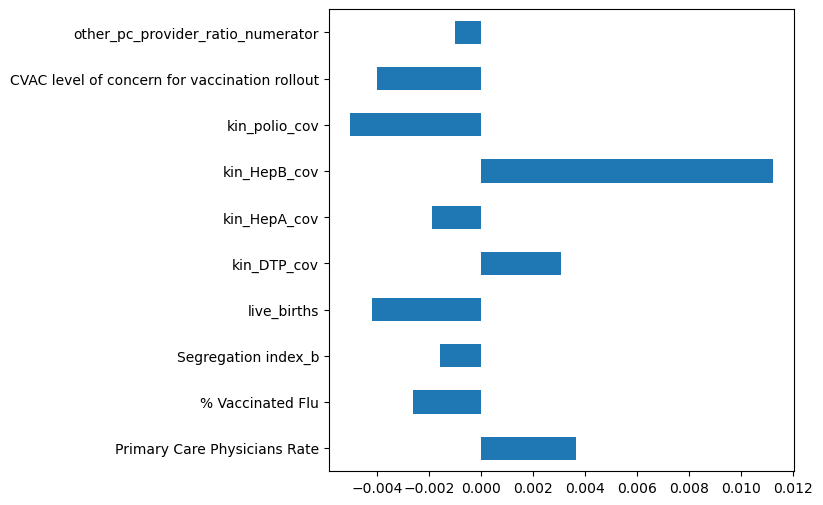

In [558]:
coef_df_top10 = coef_df['coefficients'].head(10)
# Plot horizontally
coef_df_top10.plot.barh(figsize=(6,6))

Text(0, 0.5, 'Predicted')

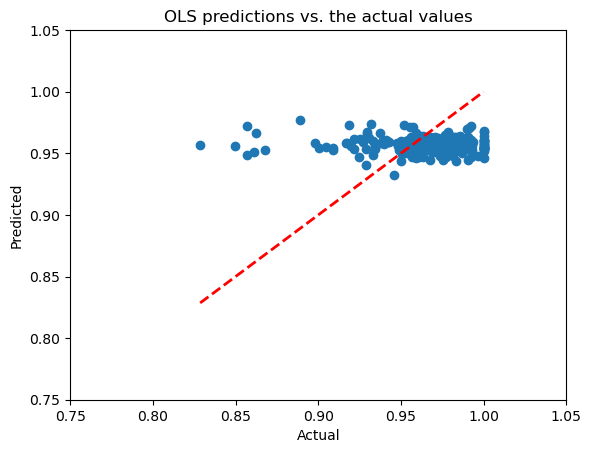

In [559]:
# Build a scatterplot
plt.scatter(y_test, y_pred)
# Get the range of your data to draw the line 
line_start = min(y_test.min(), y_pred.min())
line_end = max(y_test.max(), y_pred.max())

# Add a line for perfect correlation. 
plt.plot([line_start, line_end], [line_start, line_end], color='red', linestyle='--', linewidth=2, label='Perfect prediction')

# Set axis limits starting at 0.75
plt.xlim(0.75, line_end * 1.05)  # Add 5% padding
plt.ylim(0.75, line_end * 1.05)

# Label it nicely
plt.title("OLS predictions vs. the actual values")
plt.xlabel ("Actual")
plt.ylabel("Predicted")

In [560]:
# fit model on test data

In [561]:
ols1.fit(X_test, y_test)
ols1test_results = ols1.named_steps['regressor'].model_
# print(ols1test_results.summary())

In [562]:
print(f"R-squared: {ols1test_results.rsquared:.4f}")
print(f"Adjusted R-squared: {ols1test_results.rsquared_adj:.4f}")
print(f"MSE: {ols1test_results.mse_resid:.4f}")
print(f"RMSE: {np.sqrt(ols1test_results.mse_resid):.4f}")

R-squared: 0.0827
Adjusted R-squared: 0.0340
MSE: 0.0010
RMSE: 0.0310


In [563]:
# Extract coefficients
coefs = ols1test_results.params  # pandas Series with index = feature names
coefs = coefs[1:] # slice off first column of array which is the constant we added
coefs.shape 

(10,)

In [564]:
# Get the SelectKBest step from your pipeline
selector = ols1.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))

10


In [565]:
# Set index to feature name, extract coefficient series
coef_df = pd.DataFrame({'coefficients': coefs}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)

,coefficients,coef_magnitude
Population,-0.058752,0.058752
% Less Than 18 Years of Age,0.038749,0.038749
# Primary Care Physicians,0.032403,0.032403
# Food Insecure,-0.014678,0.014678
Infant Mortality Rate,0.006185,0.006185
Other Primary Care Provider Rate,-0.002720,0.002720
other_pc_provider_ratio_numerator,-0.002708,0.002708
Primary Care Physicians Rate,-0.002404,0.002404
# Uninsured Children,0.001199,0.001199
Estimated hesitant or unsure,0.000727,0.000727


interesting to see that most import covariates differs slightly from the training to test set. Uninsurance and the SVI categories are still big drivers of immunization coverate, but the median household income is now in the top five as well as the % of the population that is food insecure.

### Ridge

In [566]:
# Create pipeline with the wrapper
ridge1 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 10 features
    ("ridge", Ridge())
])

In [567]:
# parameter grid for pipeline object
# note that dictionary keys must match the pipeline steps specified above
param_grid = {
    'feature_selection__k': [5, 10, 20, 30, 'all'], 
    'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000, 1000000]
}

In [568]:
# define cross validation object for 
ridge_cv = GridSearchCV(
    ridge1,
    param_grid,
    cv=kf,
    scoring={
        'mse': 'neg_mean_squared_error',
        'r2': 'r2'
    },
    refit='mse', # use MSE to choose best estimator
    n_jobs=-1
)

GridSearchCV
 └── best_estimator_  ← Pipeline
      ├── feature_selection (SelectKBest)
      └── ridge (Ridge)

In [569]:
# fit to training data
ridge_cv.fit(X_train, y_train)

GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectKBest(score_func=<function f_regression at 0x14b4f2660>)),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'feature_selection__k': [5, 10, 20, 30, 'all'],
                         'ridge__alpha': [0.1, 1, 10, 100, 1000, 10000,
                                          1000000]},
             refit='mse',
             scoring={'mse': 'neg_mean_squared_error', 'r2': 'r2'})

In [570]:
# check optimal parameters
print("Tuned ridge paramaters: {}".format(ridge_cv.best_params_))
# check training score
print("Tuned ridge root mean squared error score: {}".format(round(math.sqrt(-ridge_cv.best_score_),5))) # negative sq root of the negative mean squared error


Tuned ridge paramaters: {'feature_selection__k': 30, 'ridge__alpha': 1000}
Tuned ridge root mean squared error score: 0.04299


Best hyperparameter showed that alpha was 1 million, so there is a huge penalty put on larger coefficients in this model. Remember that as alpha increases, Rsquared (performance) decreases.

In [571]:
# extract the R squared of the model with the best model (best mse)
best_idx = ridge_cv.best_index_
best_r2 = ridge_cv.cv_results_['mean_test_r2'][best_idx]
print(best_r2)

-0.009621327127264202


In [572]:
# Get the SelectKBest step from your pipeline to examine features
best_pipe = ridge_cv.best_estimator_
selector = best_pipe.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))
print(selected_features)

30
['# Primary Care Physicians', 'Primary Care Physicians Rate', '% Vaccinated Flu', '% Children in Poverty', 'Infant Mortality Rate', '# Uninsured Children', '% Uninsured Children', '# Food Insecure', '% Food Insecure', 'Segregation index_b', 'Other Primary Care Provider Rate', 'Median Household Income', '% Enrolled in Free or Reduced Lunch', 'Population', '% Female', '% Rural', 'year', '% Broadband Access', '% Less Than 18 Years of Age', 'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_polio_cov', 'kin_varic_cov', 'Estimated hesitant', 'Estimated hesitant or unsure', 'Social Vulnerability Index (SVI)', 'CVAC level of concern for vaccination rollout', 'other_pc_provider_ratio_numerator']


In [573]:
# extract model from pipeline to look at coefficients
ridge_model = best_pipe.named_steps['ridge']

In [574]:
coef_df = pd.DataFrame({'coefficients': ridge_model.coef_}, index = selected_features)
coef_df['coef_magnitude'] = abs(coef_df['coefficients'])
coef_df.sort_values(by=['coef_magnitude'], ascending=False)
coef_df_top10 = coef_df['coefficients'].head(10)
coef_df

,coefficients,coef_magnitude
# Primary Care Physicians,0.000252,0.000252
Primary Care Physicians Rate,0.001258,0.001258
% Vaccinated Flu,-0.001258,0.001258
% Children in Poverty,0.000440,0.000440
Infant Mortality Rate,-0.000396,0.000396
# Uninsured Children,0.000244,0.000244
% Uninsured Children,0.000135,0.000135
# Food Insecure,0.000200,0.000200
% Food Insecure,0.000468,0.000468
Segregation index_b,-0.000738,0.000738


<Axes: >

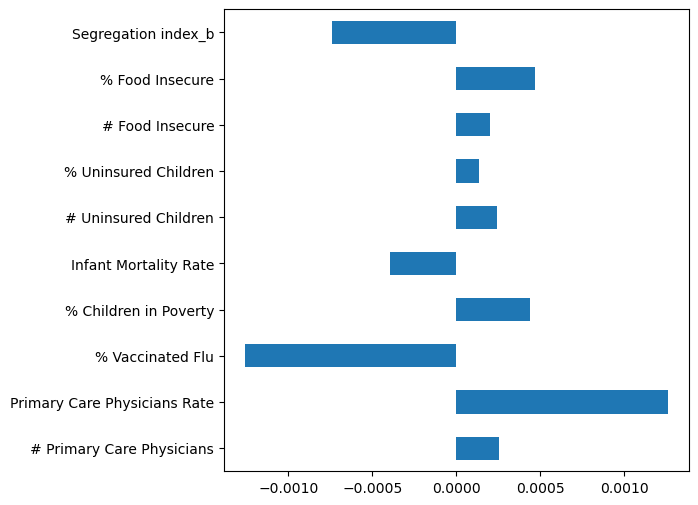

In [575]:
# Plot horizontally
coef_df_top10.plot.barh(figsize=(6,6))

Fit the model on test data

In [576]:
y_pred = best_pipe.predict(X_test)

In [577]:
r2 = best_pipe.score(X_test, y_test)
print(f"Test R²: {r2:.4f}")
mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {mse:.4f}")


Test R²: -0.0537
Test MSE: 0.0010


Examine performance on test data visually

Text(0, 0.5, 'Predicted')

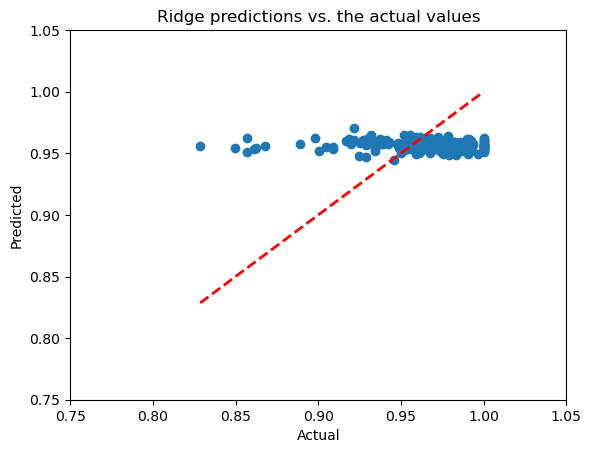

In [578]:
# Build a scatterplot
plt.scatter(y_test, y_pred)
# Get the range of your data to draw the line 
line_start = min(y_test.min(), y_pred.min())
line_end = max(y_test.max(), y_pred.max())

# Add a line for perfect correlation. 
plt.plot([line_start, line_end], [line_start, line_end], color='red', linestyle='--', linewidth=2, label='Perfect prediction')

# Set axis limits starting at 0.5
plt.xlim(0.75, line_end * 1.05)  # Add 5% padding
plt.ylim(0.75, line_end * 1.05)

# Label it nicely
plt.title("Ridge predictions vs. the actual values")
plt.xlabel ("Actual")
plt.ylabel("Predicted")

Test Ridge model on Test data

Model did better on the test data than on the train data. Possibly it is under fitting? 

**Question**: Why did the best score during tuning occur when there was the largest alpha (penalty) on high coefficients which I didn't know was possible while underfitting. 

### XGBoost

In [579]:
# Create the pipeline
xg_pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)),
    ('regressor', xgb.XGBRegressor())
])

# Define parameter grid - use double underscore to specify pipeline step
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 1000000],
    'regressor__max_depth': [2, 6, 10, 14],
    'regressor__eta': [0.5, 1.0, 1.5]
}

# create CV object
xgboost_cv = GridSearchCV(xg_pipeline, param_grid, cv=kf, 
                          scoring='neg_mean_squared_error', verbose=1)

In [580]:
#xgboost_cv = GridSearchCV(xg, param_grid, cv=kf) 
xgboost_cv.fit(X_train, y_train)
# no transform or fit_transform method on XGBoost
xgboost_cv.score(X_train, y_train)

Fitting 5 folds for each of 84 candidates, totalling 420 fits


-0.0018470529817251238

In [581]:
# Get best model and results
best_model = xgboost_cv.best_estimator_
# check optimal parameters
print("Tuned ridge paramaters: {}".format(xgboost_cv.best_params_))
# check training score
print("Tuned ridge root mean squared error score: {}".format(round(math.sqrt(-xgboost_cv.best_score_),5))) # negative sq root of the negative mean squared error


Tuned ridge paramaters: {'regressor__alpha': 10.0, 'regressor__eta': 0.5, 'regressor__max_depth': 2}
Tuned ridge root mean squared error score: 0.04309


In [582]:
# Use the best model to calculate R² on training data
train_r2 = best_model.score(X_train, y_train)
print(f"Train R²: {train_r2:.10f}")

Train R²: -0.0000000000


Horrible performance with slightly negative/zero R squared value. Although the RMSE is on par with other models...

In [583]:
# Get the SelectKBest step from your pipeline to examine features
selector = best_model.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))
print(selected_features)

10
['Primary Care Physicians Rate', '% Vaccinated Flu', 'Segregation index_b', 'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_polio_cov', 'CVAC level of concern for vaccination rollout', 'other_pc_provider_ratio_numerator']


In [584]:
# extract model regressor step from pipeline to look at feature importances
xgboost_model = best_model.named_steps['regressor']
xgboost_model.feature_importances_

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [585]:
importance_df = pd.DataFrame({'coefficients': xgboost_model.feature_importances_}, index = selected_features)
# nothing to plot

<Axes: >

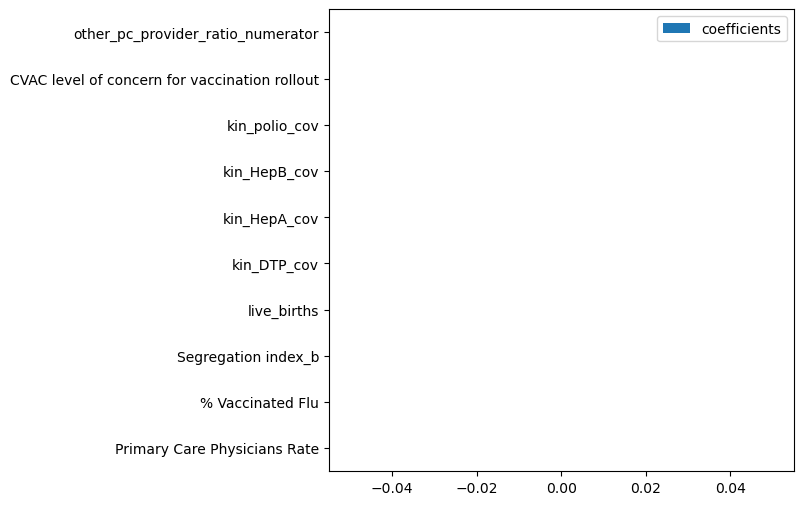

In [586]:
# Plot horizontally
importance_df.plot.barh(figsize=(6,6))

No better than a dummy regressor

### RandomForest

In [205]:
# Create the pipeline
rf_pipeline = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)),
    ('regressor', RandomForestRegressor())
])

# Define parameter grid - use double underscore to specify pipeline step
param_grid = {
    'regressor__min_samples_leaf': [1,3,5],
    'regressor__max_depth': [2, 6, 10, 14],
    'regressor__min_samples_split': [2, 5, 8],
    'regressor__max_features': ["sqrt", "log2"],
    'regressor__n_estimators': [100,150,200],
}

# create CV object
rf_cv = GridSearchCV(rf_pipeline, param_grid, cv=kf, 
                          scoring='neg_mean_squared_error', verbose=1)

In [206]:
# TAKES A FEW MINUTES TO RUN!!!
rf_cv.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=Pipeline(steps=[('feature_selection',
                                        SelectKBest(score_func=<function f_regression at 0x14b4f2660>)),
                                       ('regressor', RandomForestRegressor())]),
             param_grid={'regressor__max_depth': [2, 6, 10, 14],
                         'regressor__max_features': ['sqrt', 'log2'],
                         'regressor__min_samples_leaf': [1, 3, 5],
                         'regressor__min_samples_split': [2, 5, 8],
                         'regressor__n_estimators': [100, 150, 200]},
             scoring='neg_mean_squared_error', verbose=1)

In [207]:
# negative means sq error on training data
rf_cv.score(X_train, y_train)

-0.0017434620691933788

In [200]:
# Get R² on training data (using CV best estimator)
best_rf_model = rf_cv.best_estimator_
train_r2 = best_rf_model.score(X_train, y_train)
print(f"Train R²: {train_r2:.10f}")

Train R²: 0.0584388236


In [739]:
print("Tuned random forest paramaters: {}".format(rf_cv.best_params_))


Tuned random forest paramaters: {'regressor__max_depth': 2, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 150}


In [217]:
# Get the SelectKBest step from your pipeline to examine features
selector = best_rf_model.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(len(selected_features))
print(selected_features)

10
['Primary Care Physicians Rate', '% Vaccinated Flu', 'live_births', 'kin_DTP_cov', 'kin_HepA_cov', 'kin_HepB_cov', 'kin_polio_cov', 'CVAC level of concern for vaccination rollout', 'OH__Moderate Concern', 'OH__small']


In [ ]:
# examine feature importances

In [218]:
# Extract feature importances from regressor step
rf_model = best_rf_model.named_steps["regressor"]  
rf_importances = rf_model.feature_importances_

# Create a DataFrame
rf_importance_df = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_importances
}).sort_values('importance', ascending=False)

print(rf_importance_df)

                                         feature  importance
7  CVAC level of concern for vaccination rollout    0.217600
4                                   kin_HepA_cov    0.180628
0                   Primary Care Physicians Rate    0.134417
3                                    kin_DTP_cov    0.106423
1                               % Vaccinated Flu    0.104831
5                                   kin_HepB_cov    0.090509
2                                    live_births    0.086219
6                                  kin_polio_cov    0.073503
8                           OH__Moderate Concern    0.005870
9                                      OH__small    0.000000


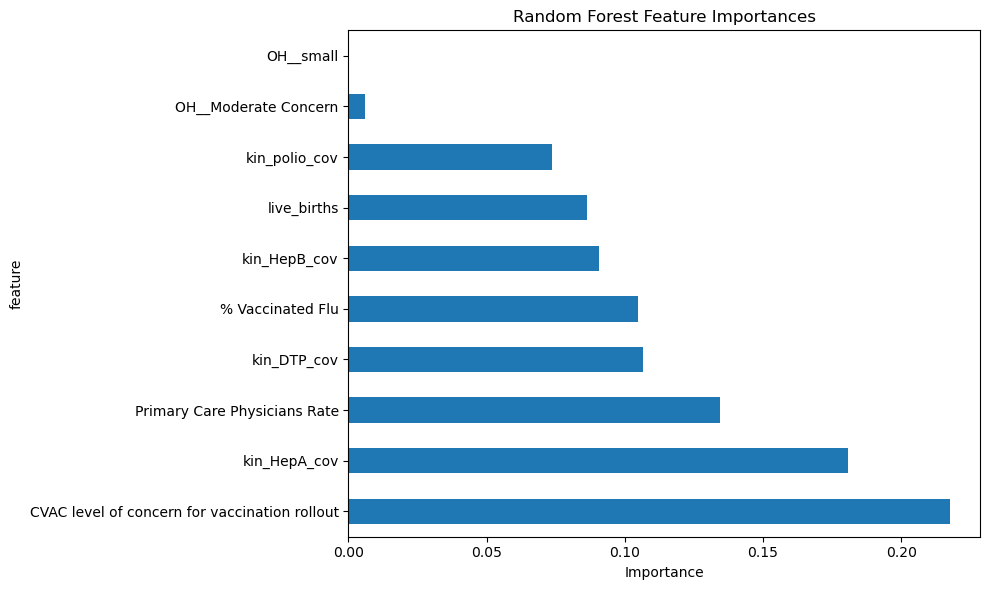

In [220]:
rf_importance_df.plot.barh(x='feature', y='importance', figsize=(10, 6), legend=False)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

Fit model to training data

In [214]:
rf_cv.score(X_test, y_test)

-0.0010386951635388512

Negative R² - model is severely overfitting the training data and fails to generalize to unseen data

In [ ]:
Of the various models tried, Ridge model has generalized best to new data.

In [198]:
# Get R² on training data (using CV best estimator)
best_rf_model = rf_cv.best_estimator_
train_r2 = best_rf_model.score(X_train, y_train)
print(f"Train R²: {train_r2:.10f}")

Train R²: 0.0584388236


### 3c. Year-specific models

#### Create data sets to run model for each year separately

From the group split data sets, create four new data sets to run the model separately on each year and see how feature inmportance may have shifted across the four years.

In [587]:
# split the train/test dfs by year
print("X_train shape", X_train_df.shape,
     "\ny_train shape", y_train_df.shape,
     "\nX_test shape", X_test_df.shape,
     "\ny_test shape", y_test_df.shape
     )

X_train shape (797, 33) 
y_train shape (797, 1) 
X_test shape (199, 33) 
y_test shape (199, 1)


In [588]:
# make yearly masks for training data matrix
X_2023_mask = X_train_df['year']==2023
X_2022_mask = X_train_df['year']==2022
X_2021_mask = X_train_df['year']==2021
X_2020_mask = X_train_df['year']==2020

X_train_2023 = X_train_df.loc[X_2023_mask,:]
X_train_2022 = X_train_df.loc[X_2022_mask,:]
X_train_2021 = X_train_df.loc[X_2021_mask,:]
X_train_2020 = X_train_df.loc[X_2020_mask,:]

y_train_2023 = y_train_df.loc[X_2023_mask,:]
y_train_2022 = y_train_df.loc[X_2022_mask,:]
y_train_2021 = y_train_df.loc[X_2021_mask,:]
y_train_2020 = y_train_df.loc[X_2020_mask,:]

print("Shape of 2023 dfs:", X_train_2023.shape, y_train_2023.shape)
print("Shape of 2022 dfs:", X_train_2022.shape, y_train_2022.shape)
print("Shape of 2021 dfs:", X_train_2021.shape, y_train_2021.shape)
print("Shape of 2020 dfs:", X_train_2020.shape, y_train_2020.shape)

Shape of 2023 dfs: (200, 33) (200, 1)
Shape of 2022 dfs: (198, 33) (198, 1)
Shape of 2021 dfs: (199, 33) (199, 1)
Shape of 2020 dfs: (200, 33) (200, 1)


In [589]:
# make yearly masks for test data 
X_2023_mask = X_test_df['year']==2023
X_2022_mask = X_test_df['year']==2022
X_2021_mask = X_test_df['year']==2021
X_2020_mask = X_test_df['year']==2020

X_test_2023 = X_test_df.loc[X_2023_mask,:]
X_test_2022 = X_test_df.loc[X_2022_mask,:]
X_test_2021 = X_test_df.loc[X_2021_mask,:]
X_test_2020 = X_test_df.loc[X_2020_mask,:]

y_test_2023 = y_test_df.loc[X_2023_mask,:]
y_test_2022 = y_test_df.loc[X_2022_mask,:]
y_test_2021 = y_test_df.loc[X_2021_mask,:]
y_test_2020 = y_test_df.loc[X_2020_mask,:]

print("Shape of 2023 dfs:", X_test_2023.shape, y_test_2023.shape)
print("Shape of 2022 dfs:", X_test_2022.shape, y_test_2022.shape)
print("Shape of 2021 dfs:", X_test_2021.shape, y_test_2021.shape)
print("Shape of 2020 dfs:", X_test_2020.shape, y_test_2020.shape)

Shape of 2023 dfs: (49, 33) (49, 1)
Shape of 2022 dfs: (50, 33) (50, 1)
Shape of 2021 dfs: (50, 33) (50, 1)
Shape of 2020 dfs: (50, 33) (50, 1)


#### Convert to arrays

In [ ]:
type(y_test

In [599]:
# Process X_train and X_test data sets
# Convert dfs to arrays
# Make sure there indices are numeric before modeling, delete 'column', rename and convert to numpy

for df in [X_train_2023, X_train_2022, X_train_2021, X_train_2020]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    # print(df.columns)
    X_train = df.to_numpy()

for df in [X_test_2023, X_test_2022,X_test_2021,X_test_2020]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    # print(df.columns)
    X_test = df.to_numpy()

Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=200, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=198, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=199, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=200, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=49, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modification? False
RangeIndex(start=0, stop=50, step=1)
Dataframe has county as a column AFTER modification? False
5
Dataframe has county as a column BEFORE modifica

#### Run LR on each year - TO FIX

In [596]:
# create pipeline and fit to data for 2020 data
lr12020 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # select top 10 features
    ("regressor", LinearRegression())
])

In [597]:
lr12020.fit(X_train_2020, y_train_2020)

ValueError: could not convert string to float: 'Anderson'

In [366]:
# Get the SelectKBest step from your pipeline
selector = lr12020.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

In [367]:
# Extract feature importance (coefficients from pipeline)
coefs = lr12020.named_steps["regressor"].coef_.ravel()
coef_df_2020 = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series_2020 = coef_df_2020.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_2020_sorted = coef_series_2020.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs_2020 = coef_series_2020_sorted.head(10)
print(top10_coefs_2020)

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: coefficient, dtype: float64


In [369]:
# create pipeline and fit to data for 2021 data
lr12021 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # select top 10 features
    ("regressor", LinearRegression())
])
# fit pipeline
lr12021.fit(X_train, y_train)

# Extract selected features from SelectKBest step of pipeline
selector = lr12021.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

# Extract feature importance (coefficients from pipeline)
coefs = lr12021.named_steps["regressor"].coef_.ravel()
coef_df_2021 = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series_2021 = coef_df_2021.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_2021_sorted = coef_series_2021.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs_2021 = coef_series_2021_sorted.head(10)
print(top10_coefs_2021)

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: coefficient, dtype: float64


In [351]:
# create pipeline and fit to data for 2022 data
lr12022 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # select top 10 features
    ("regressor", LinearRegression())
])
# fit pipeline
lr12022.fit(X_train, y_train)

# Extract selected features from SelectKBest step of pipeline
selector = lr12022.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

# Extract feature importance (coefficients from pipeline)
coefs = lr12022.named_steps["regressor"].coef_.ravel()
coef_df_2022 = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series_2022 = coef_df_2022.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_2022_sorted = coef_series_2022.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs_2022 = coef_series_2022_sorted.head(10)
print(top10_coefs_2022)

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: coefficient, dtype: float64


In [352]:
# create pipeline and fit to data for 2023 data
lr12023 = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # select top 10 features
    ("regressor", LinearRegression())
])
# fit pipeline
lr12023.fit(X_train, y_train)

# Extract selected features from SelectKBest step of pipeline
selector = lr12023.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]

# Extract feature importance (coefficients from pipeline)
coefs = lr12023.named_steps["regressor"].coef_.ravel()
coef_df_2023 = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series_2023 = coef_df_2023.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_2023_sorted = coef_series_2023.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs_2023 = coef_series_2023_sorted.head(10)
print(top10_coefs_2023)

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: coefficient, dtype: float64


In [353]:
# combine the feature coefficient tables for each year


In [362]:
top10_coefs_2020

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: 2020, dtype: float64

In [363]:
top10_coefs_2021

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: 2021, dtype: float64

In [361]:
# Make a dictionary where key=year and value=series
coef_comparison = pd.DataFrame({
    '2020': top10_coefs_2020,
    '2021': top10_coefs_2021,
    '2022': top10_coefs_2022,
    '2023': top10_coefs_2023
})

print(coef_comparison)

                                                   2020      2021      2022  \
feature                                                                       
kin_HepB_cov                                   0.011213  0.011213  0.011213   
kin_polio_cov                                 -0.005043 -0.005043 -0.005043   
live_births                                   -0.004206 -0.004206 -0.004206   
CVAC level of concern for vaccination rollout -0.003993 -0.003993 -0.003993   
Primary Care Physicians Rate                   0.003629  0.003629  0.003629   
kin_DTP_cov                                    0.003063  0.003063  0.003063   
% Vaccinated Flu                              -0.002611 -0.002611 -0.002611   
kin_HepA_cov                                  -0.001878 -0.001878 -0.001878   
Segregation index_b                           -0.001568 -0.001568 -0.001568   
other_pc_provider_ratio_numerator             -0.001017 -0.001017 -0.001017   

                                                   

In [354]:
#coef_series = [top10_coefs_2023, top10_coefs_2022, top10_coefs_2021, top10_coefs_2020]
#years = [2023,2022,2021,2020]
#for s, year in zip(coef_series, years):
#    s.name = str(year)


In [355]:
top10_coefs_2023

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
kin_DTP_cov                                      0.003063
% Vaccinated Flu                                -0.002611
kin_HepA_cov                                    -0.001878
Segregation index_b                             -0.001568
other_pc_provider_ratio_numerator               -0.001017
Name: 2023, dtype: float64

In [360]:
coef_df = pd.concat(coef_series, axis=1)
coef_df = coef_df.sort_index()
coef_df

,2023,2022,2021,2020
feature,,,,
% Vaccinated Flu,-0.002611,-0.002611,-0.002611,-0.002611
CVAC level of concern for vaccination rollout,-0.003993,-0.003993,-0.003993,-0.003993
Primary Care Physicians Rate,0.003629,0.003629,0.003629,0.003629
Segregation index_b,-0.001568,-0.001568,-0.001568,-0.001568
kin_DTP_cov,0.003063,0.003063,0.003063,0.003063
kin_HepA_cov,-0.001878,-0.001878,-0.001878,-0.001878
kin_HepB_cov,0.011213,0.011213,0.011213,0.011213
kin_polio_cov,-0.005043,-0.005043,-0.005043,-0.005043
live_births,-0.004206,-0.004206,-0.004206,-0.004206


,2023,2022,2021,2020
feature,,,,
% Vaccinated Flu,-0.002611,-0.002611,-0.002611,-0.002611
CVAC level of concern for vaccination rollout,-0.003993,-0.003993,-0.003993,-0.003993
Primary Care Physicians Rate,0.003629,0.003629,0.003629,0.003629
Segregation index_b,-0.001568,-0.001568,-0.001568,-0.001568
kin_DTP_cov,0.003063,0.003063,0.003063,0.003063
kin_HepA_cov,-0.001878,-0.001878,-0.001878,-0.001878
kin_HepB_cov,0.011213,0.011213,0.011213,0.011213
kin_polio_cov,-0.005043,-0.005043,-0.005043,-0.005043
live_births,-0.004206,-0.004206,-0.004206,-0.004206


# 4. Temporal Split - Investigate model capacity to predict future MMR coverage

## 4a. Load data


In [617]:
os.chdir('/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split/')

In [604]:
print(os.getcwd())  # get current working directory

/Users/grace/Documents/GitHubRepos/capstone2_immunization/processed_data/temporal_split


In [618]:
file_names = ["X1_train.csv", 
              "y1_train.csv", 
              "X2_test.csv", 
              "y2_test.csv"]

In [660]:
# Import data to data frames
X1_train_df = import_multiple_csv_to_pandas(file_names[0])
y1_train_df = import_multiple_csv_to_pandas(file_names[1])
X2_test_df = import_multiple_csv_to_pandas(file_names[2])
y2_test_df = import_multiple_csv_to_pandas(file_names[3])


DataFrame before conversion:
NaN count per column:
county_name                                        0
% Low Birthweight                                513
# Primary Care Physicians                         60
Primary Care Physicians Rate                      60
% Vaccinated Flu                                   3
% Children in Poverty                              0
Infant Mortality Rate                            520
# Uninsured Children                               0
% Uninsured Children                               0
# Food Insecure                                    0
% Food Insecure                                    0
Segregation index_b                              247
Other Primary Care Provider Rate                  14
Median Household Income                            0
% Enrolled in Free or Reduced Lunch                0
Population                                         0
% Female                                         248
% Rural                                        

In [661]:
#check shape of dfs
print(f"X1_train shape: {X1_train_df.shape}\nX2_test shape is{X2_test_df.shape}.")
print(f"y1_train shape: {y1_train_df.shape}\ny2_test shape is{y2_test_df.shape}.")

X1_train shape: (747, 34)
X2_test shape is(249, 34).
y1_train shape: (747, 1)
y2_test shape is(249, 1).


In [662]:
# Drop pesky columns and rename dfs
X1_train_df = X1_train_df.drop('seg_missing_bool', axis=1)
X2_test_df  = X2_test_df.drop('seg_missing_bool', axis=1)

In [663]:
#check shape of dfs
print(f"X1_train shape: {X1_train_df.shape}\nX2_test shape is{X2_test_df.shape}.")
print(f"y1_train shape: {y1_train_df.shape}\ny2_test shape is{y2_test_df.shape}.")

X1_train shape: (747, 33)
X2_test shape is(249, 33).
y1_train shape: (747, 1)
y2_test shape is(249, 1).


In [664]:
# Convert y_test and y_train to numpy arrays
y_test = y2_test_df.to_numpy()
y_train = y1_train_df.to_numpy()

print("y_test array:")
print(" Shape:", y_test.shape)
print(" Dtype:", y_test.dtype)

print("y_train array:")
print(" Shape:", y_train.shape)
print(" Dtype:", y_train.dtype)

y_test array:
 Shape: (249, 1)
 Dtype: float64
y_train array:
 Shape: (747, 1)
 Dtype: float64


In [665]:
# check to see if country_name is in the X_train file, will need this for imputation fxn
print('county_name' in (X1_train_df.columns))

# extract index to X_train
feature_names = X1_train_df.columns.to_list()

True


## 4b. Impute and standardizze

In [666]:
# apply standardizer fxn to X_train and X_test
X_train_processed, X_test_processed = standardizze(X_train_df, X_test_df)

***** Dataframe that will not be standardized*****

 Columns that wont be standardized: ['year', 'county_name']
 Is county_name in list that of cols that will not be standardized? True


***** Dataframe to be standardized*****

Overlap: set()
Dataframe to be standardized - shape: (747, 31)

df_train of columns that will not be standardized has this shape: (747, 2)
df_test of columns that will not be standardized has this shape: (249, 2)

***** Scaling subsets of the data .... *****

Standardized X training df has this shape: (747, 31)
Standardized X test df has this shape: (249, 31)

***** Assess changes and save with select standardized columns *****

New version of X_train saved over the original version with standardized values
New version of X_test saved over the original version with standardized values
Returning X_train and X_test.
X_train type: <class 'pandas.core.frame.DataFrame'>
X_test type: <class 'pandas.core.frame.DataFrame'>


In [667]:
# Apply the impute_please fxn to X_train and X_test
# remember the impute_please function requires 'county_name' as a column
X_train_processed, X_test_processed = impute_please(X_train_processed, X_test_processed, 0.03)

<class 'pandas.core.frame.DataFrame'>
Comparing years 2020 to 2022
Imputing values for columns with <3.0% change.....
These columns are: []
Final results of simple imputation with median for select features:
Training df:
Series([], dtype: float64)

Testing df:
Series([], dtype: float64)

Imputing values for 33 columns with missing values....
These columns are: ['Other Primary Care Provider Rate', 'kin_DTP_cov', '# Uninsured Children', 'Estimated strongly hesitant', '% Vaccinated Flu', '% Rural', 'Estimated hesitant or unsure', 'Infant Mortality Rate', 'kin_HepA_cov', '% Female', '% Uninsured Children', 'Median Household Income', 'Population', 'CVAC level of concern for vaccination rollout', 'Segregation index_b', 'kin_HepB_cov', 'Primary Care Physicians Rate', '% Food Insecure', 'other_pc_provider_ratio_numerator', 'kin_varic_cov', 'county_name', '% Low Birthweight', 'Social Vulnerability Index (SVI)', '# Food Insecure', '% Less Than 18 Years of Age', 'live_births', 'Estimated hesitant

## 4c. Convert index to numeric and remove county_name before modeling

Using the X_train_processed and X_test_processed dfs created in last step...

In [668]:
# Process X_train and X_test
# Make sure there indices are numeric before modeling, delete 'column', rename and convert to numpy

for df in [X_train_processed]:
    print(X_train_processed.isna().sum())
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_train = df.to_numpy()

for df in [X_test_processed]:
    print(f"Dataframe has county as a column BEFORE modification? {['county_name'] in df.columns.to_list()}")
    df = df.sort_values(by = ['county_name','year'])
    df.drop(columns = ['county_name'], axis =1, inplace =True)
    df = df.reset_index(drop=True)
    print(df.index)
    print(f"Dataframe has county as a column AFTER modification? {['county_name'] in df.columns.to_list()}")
    print(df.index.to_list()[5])
    X_test = df.to_numpy()

% Low Birthweight                                0
# Primary Care Physicians                        0
Primary Care Physicians Rate                     0
% Vaccinated Flu                                 0
% Children in Poverty                            0
Infant Mortality Rate                            0
# Uninsured Children                             0
% Uninsured Children                             0
# Food Insecure                                  0
% Food Insecure                                  0
Segregation index_b                              0
Other Primary Care Provider Rate                 0
Median Household Income                          0
% Enrolled in Free or Reduced Lunch              0
Population                                       0
% Female                                         0
% Rural                                          0
% Broadband Access                               0
% Less Than 18 Years of Age                      0
live_births                    

In [669]:
# last data type and shape checks
print(f"X_train type: {type(X_train)}\nX_test type is{type(X_test)}.")
print(f"X_train shape: {X_train.shape}\nX_test type is{X_test.shape}.")

print(f"y_train type: {type(y_train)}\ny_test type is{type(y_test)}.")
print(f"y_train shape: {y_train.shape}\ny_test shape is{y_test.shape}.")

feature_names.remove('county_name')
print("Length of feature_names:", len(feature_names))

X_train type: <class 'numpy.ndarray'>
X_test type is<class 'numpy.ndarray'>.
X_train shape: (747, 32)
X_test type is(249, 32).
y_train type: <class 'numpy.ndarray'>
y_test type is<class 'numpy.ndarray'>.
y_train shape: (747, 1)
y_test shape is(249, 1).
Length of feature_names: 32


In [670]:
# flatten y arrays
y_test = y_test.ravel()
y_train = y_train.ravel()

#print(f"y_train type: {type(y_train)}\ny_test type is{type(y_test)}.")
print(f"y_train shape: {y_train.shape}\ny_test shape is{y_test.shape}.")

y_train shape: (747,)
y_test shape is(249,).


In [731]:
#Check logit transformation
print("Mean of y_train:",np.mean(y_train))
print("Mean of y_test:",np.mean(y_test))

Mean of y_train: 0.9564394059599293
Mean of y_test: 0.9622380064357436


## 4d. LR Models

In [732]:
# specify cross validation setup, same as at beginning of file
kf = KFold(n_splits=5, shuffle=True, random_state=1)


lrp - for linear regression predict

In [672]:
# create pipeline and fit to data
lrp = Pipeline([
    ('feature_selection', SelectKBest(score_func=score_func, k=10)), # Select top 5 features
    ("regressor", LinearRegression())
])


In [673]:
lrp.fit(X_train, y_train)

Pipeline(steps=[('feature_selection',
                 SelectKBest(score_func=<function f_regression at 0x14b4f2660>)),
                ('regressor', LinearRegression())])

In [674]:
# calculate R squared 
lrp.score(X_train, y_train)

0.0124636989237763

In [678]:
neg_mse = neg_mse_scorer(lrp, X_train, y_train)
print(f"Negative MSE: {neg_mse}")
print(f"RMSE: {np.sqrt(-neg_mse)}")

Negative MSE: -0.0013074485574957424
RMSE: 0.03615865812631523


Pretty poor fit on training data

In [675]:
# Get the SelectKBest step from your pipeline
selector = lrp.named_steps["feature_selection"]  
# Get boolean mask of selected features (True = selected, False = not selected)
selected_mask = selector.get_support()
# Get the names of the selected features
selected_features = [feature_names[i] for i, selected in enumerate(selected_mask) if selected]
print(selected_features)

['# Primary Care Physicians', 'Primary Care Physicians Rate', '% Vaccinated Flu', 'Infant Mortality Rate', '% Uninsured Children', '% Food Insecure', 'Segregation index_b', 'Population', 'kin_HepA_cov', 'kin_polio_cov']


In [676]:
# Extract feature importance (coefficients from pipeline)
coefs = lrp.named_steps["regressor"].coef_.ravel()
coef_df = pd.DataFrame({
    "feature": selected_features,
    "coefficient": coefs
}).sort_values("coefficient", key=abs, ascending=True)

# Set index to feature name, extract coefficient series
coef_series = coef_df.set_index("feature")["coefficient"]
# Sort by absolute value
coef_series_sorted = coef_series.sort_values(key=abs, ascending=False)
# Select top 10 by magnitude
top10_coefs = coef_series_sorted.head(10)
print(top10_coefs)

feature
# Primary Care Physicians       0.010293
Population                     -0.007853
Primary Care Physicians Rate   -0.002164
Infant Mortality Rate          -0.002050
Segregation index_b            -0.001475
% Vaccinated Flu               -0.001202
% Uninsured Children            0.001134
% Food Insecure                -0.000762
kin_polio_cov                  -0.000653
kin_HepA_cov                   -0.000433
Name: coefficient, dtype: float64


(array([-0.006, -0.004, -0.002,  0.   ,  0.002,  0.004,  0.006,  0.008,
         0.01 ,  0.012,  0.014]),
 [Text(-0.006, 0, '−0.006'),
  Text(-0.004, 0, '−0.004'),
  Text(-0.002, 0, '−0.002'),
  Text(0.0, 0, '0.000'),
  Text(0.002, 0, '0.002'),
  Text(0.004, 0, '0.004'),
  Text(0.006, 0, '0.006'),
  Text(0.008, 0, '0.008'),
  Text(0.01, 0, '0.010'),
  Text(0.012000000000000002, 0, '0.012'),
  Text(0.014, 0, '0.014')])

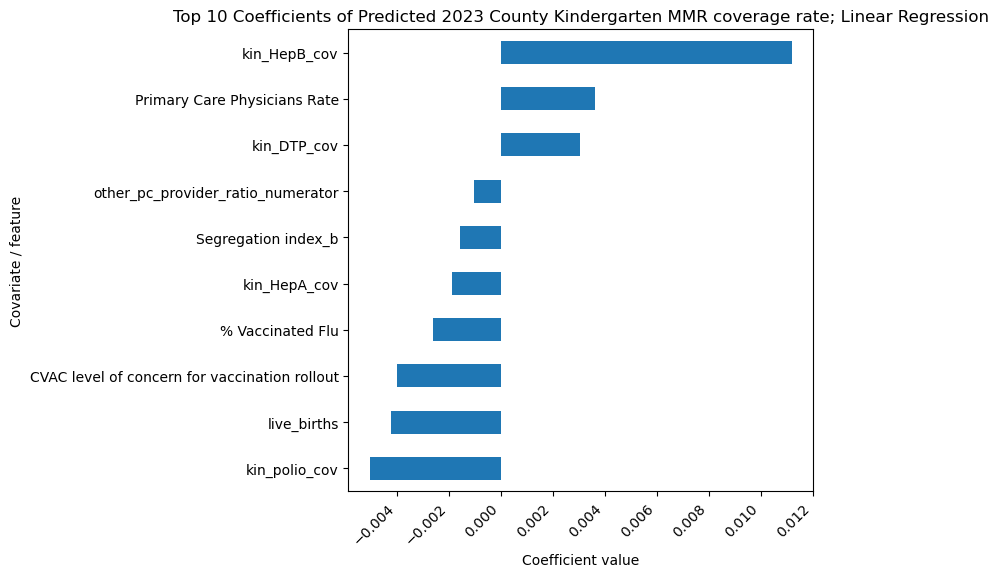

In [733]:
# Plot horizontally
_ = top10_coefs.sort_values().plot.barh(figsize=(6,6))
plt.title("Top 10 Coefficients of Predicted 2023 County Kindergarten MMR coverage rate; Linear Regression")
plt.ylabel("Covariate / feature")
plt.xlabel("Coefficient value")
# rotate x-axis tick labels
plt.xticks(rotation=45, ha='right')

feature
kin_HepB_cov                                     0.011213
kin_polio_cov                                   -0.005043
live_births                                     -0.004206
CVAC level of concern for vaccination rollout   -0.003993
Primary Care Physicians Rate                     0.003629
Name: coefficient, dtype: float64


(array([-0.006, -0.004, -0.002,  0.   ,  0.002,  0.004,  0.006,  0.008,
         0.01 ,  0.012,  0.014]),
 [Text(-0.006, 0, '−0.006'),
  Text(-0.004, 0, '−0.004'),
  Text(-0.002, 0, '−0.002'),
  Text(0.0, 0, '0.000'),
  Text(0.002, 0, '0.002'),
  Text(0.004, 0, '0.004'),
  Text(0.006, 0, '0.006'),
  Text(0.008, 0, '0.008'),
  Text(0.01, 0, '0.010'),
  Text(0.012000000000000002, 0, '0.012'),
  Text(0.014, 0, '0.014')])

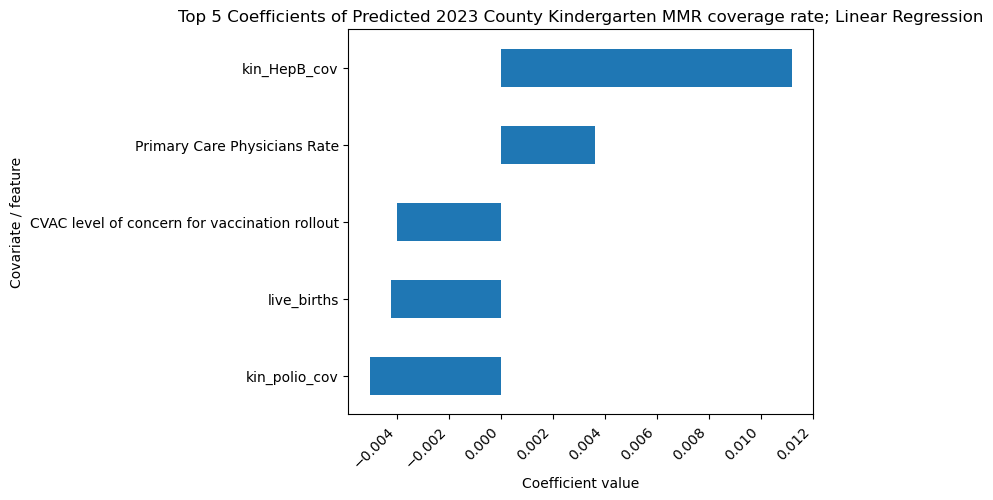

In [738]:
# Select top 5 by magnitude
top5_coefs = coef_series_sorted.head(5)
print(top5_coefs)
# Plot horizontally
_ = top5_coefs.sort_values().plot.barh(figsize=(6,5))
plt.title("Top 5 Coefficients of Predicted 2023 County Kindergarten MMR coverage rate; Linear Regression")
plt.ylabel("Covariate / feature")
plt.xlabel("Coefficient value")
# rotate x-axis tick labels
plt.xticks(rotation=45, ha='right')

Predict values for 2023

In [726]:
y_pred = lrp.predict(X_test)

In [727]:
# calculate R squared 
lrp.score(X_test, y_test)

-0.007862416854145904

In [728]:
# calculated RMSE
neg_mse = neg_mse_scorer(lrp, X_test, y_test)
print(f"Negative MSE: {neg_mse}")
print(f"RMSE: {np.sqrt(-neg_mse)}")

Negative MSE: -0.0009996964916769721
RMSE: 0.03161797734955499


Fit seemed to be slightly better on prediction but still pretty dismal

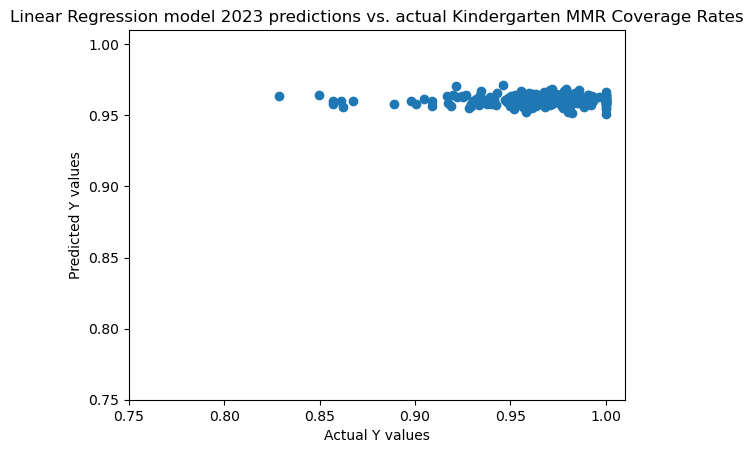

In [729]:
plt.scatter(y_test,y_pred)
# Set axis limits starting at 0.75
plt.xlim(0.75, 1.01)  # Add 5% padding
plt.ylim(0.75, 1.01)
plt.xlabel("Actual Y values")
plt.ylabel("Predicted Y values")
plt.title("Linear Regression model 2023 predictions vs. actual Kindergarten MMR Coverage Rates")
plt.show()

In [687]:
# Check if many values are at ceiling
ceiling_pct = (y_test >= .95).sum() / len(y_test) * 100
print(f"Percentage at/near ceiling (≥95%): {ceiling_pct:.1f}%")


Percentage at/near ceiling (≥95%): 56.6%
